# Dielectric loss: perturbation vs the full complex eigenproblem

A dielectric region can be lossy. With the $e^{+j\omega t}$ convention its
permittivity is complex,

$$\varepsilon_r = \varepsilon_r' - j\varepsilon_r'', \qquad
  \tan\delta = \frac{\varepsilon_r''}{\varepsilon_r'},$$

and there are two very different ways to get $Q$ out of that.

Perturbation. Solve the cavity as if it were lossless, then integrate the loss
over the field that comes out:

$$Q_{\rm diel} = \frac{\int \varepsilon_r'\,|\mathbf{E}|^2\,r\,{\rm d}r\,{\rm d}z}
                     {\int \varepsilon_r''\,|\mathbf{E}|^2\,r\,{\rm d}r\,{\rm d}z},
  \qquad \frac{1}{Q} = \frac{1}{Q_{\rm wall}} + \frac{1}{Q_{\rm diel}}.$$

This costs nothing beyond the lossless solve. It is accurate to
$O(\tan^2\delta)$, and the mode it integrates over is the *lossless* one — so the
reported frequency and field distribution do not know about the loss at all.

The full complex eigenproblem. Solve for a complex resonant frequency
directly:

$$\omega = \omega_r + j\alpha, \qquad
  Q_{\rm diel} = \frac{\omega_r}{2\alpha},$$

so $Q$, the frequency and the mode shape are all the lossy ones. This costs
roughly twice a lossless solve.

This notebook is about where the line between the two falls — and it draws that
line by measurement, not assertion.

`cavsim2d` picks for you: below $\tan\delta = 10^{-2}$ it uses perturbation,
above it the complex solve. You can override that per run with
`eigenmode_config['loss_model']`.

This notebook is live: every number and figure below is produced by running
`cavsim2d`.

In [1]:
import os
import tempfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cavsim2d import Pillbox
from cavsim2d.utils.style import apply_style, WARM

apply_style()             # the house publication style
WORK = tempfile.mkdtemp() # docs runs leave nothing behind

SWITCH_OVER = 1e-2        # the documented tan_delta at which 'auto' changes path

## 1. A cavity with somewhere for the loss to live

Perturbation theory fails in proportion to how much of the mode sits in the lossy
medium, so a thin window would hide the effect. This chamber is a 75 mm-diameter
pillbox whose bore is lined with a thick ceramic sleeve, $\varepsilon_r' = 9.8$,
from the 5 mm aperture out to $r = 20$ mm. Almost all of the TM$_{010}$ electric
energy ends up inside it.

`tan_delta` is declared alongside `eps_r`; everything else about
`add_dielectric` is unchanged.

{'material': 'ceramic', 'eps_r': 9.8, 'tan_delta': 0.001, 'maxh': 1.0, 'color': (1.0, 1.0, 0.0), 'points': None, 'z': (-10000.0, 10000.0), 'r': (2.5, 20.0)}


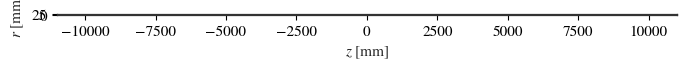

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [2]:
CHAMBER = [20.0, 37.5, 2.5, 0.0, 5.0]     # L, Req, Ri, S, L_bp  [mm]
EPS_R = 9.8                               # real permittivity of the sleeve
SLEEVE_R = (2.5, 20.0)                    # inner/outer radius [mm]
MESH = {'h': 4, 'p': 2}                   # coarse: this notebook runs 22 solves


def build(name, tan_delta):
    'The chamber with a lossy ceramic sleeve of the given loss tangent.'
    cav = Pillbox(1, CHAMBER, beampipe='both')
    cav.set_workspace(os.path.join(WORK, name))
    # z spans everything and is clipped to the cavity, so this means "full length".
    cav.add_dielectric('ceramic', EPS_R, tan_delta=tan_delta,
                       z=(-1e4, 1e4), r=SLEEVE_R, maxh=1.0)
    return cav


cav = build('preview', 1e-3)
print(cav.dielectrics[0])
cav.plot('geometry')

## 2. Run every path over four decades of loss

`eigenmode_config['loss_model']` takes `'lossless'`, `'lossy'`, or nothing at all
— leaving it out is `'auto'`, which inspects the loss tangents and switches at
$\tan\delta = 10^{-2}$.

The sleeve's loss tangent is swept with `materials`, which *overrides* the
properties of an already-declared region, so the geometry is built once and only
the material changes. Each loss tangent is solved three times: once on each forced
path, and once letting the solver choose.

Every run reports which path it actually took, as the `Q model` QOI, so nothing
below depends on predicting the choice.

In [3]:
TAN_DELTAS = [1e-4, 1e-3, 1e-2, 3e-2, 0.1, 0.3, 1.0]
SETTINGS = {'auto': {}, 'lossless': {'loss_model': 'lossless'},
            'lossy': {'loss_model': 'lossy'}}


def run(tan_delta, setting):
    'Solve TM010 once with the given loss_model setting; return its QOIs.'
    cav = build('td%g_%s' % (tan_delta, setting), tan_delta)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')   # section 5 shows the warning deliberately
        cav.eigenmode.run(polarisation='monopole', n_modes=2, mesh_config=MESH,
                          materials={'ceramic': {'tan_delta': tan_delta}},
                          **SETTINGS[setting])
    return cav.eigenmode.qois


records = []
for td in TAN_DELTAS:
    for setting in SETTINGS:
        q = run(td, setting)
        records.append({'tan_delta': td, 'loss_model': setting,
                        'Q model': q['Q model'], 'freq [MHz]': q['freq [MHz]'],
                        'Q_diel': q['Q_diel []'], 'Q_wall': q['Q_wall []'],
                        'Q': q['Q []'], 'Pdiel [W]': q['Pdiel [W]']})

sweep = pd.DataFrame(records)

# Which path each run actually took. The pivot's own axis names repeat the column
# header, so they are dropped and the loss tangents formatted compactly.
paths = sweep.pivot(index='tan_delta', columns='loss_model', values='Q model')
paths.index = [f'{t:g}' for t in paths.index]
paths.rename_axis(index='tan_delta', columns=None)

,auto,lossless,lossy
tan_delta,,,
0.0001,perturbation,perturbation,lossy
0.001,perturbation,perturbation,lossy
0.01,perturbation,perturbation,lossy
0.03,lossy,perturbation,lossy
0.1,lossy,perturbation,lossy
0.3,lossy,perturbation,lossy
1,lossy,perturbation,lossy


That table is the automatic rule, measured: `'auto'` follows `'lossless'` up to
$\tan\delta = 10^{-2}$ and `'lossy'` above it.

Note what `'lossless'` reports in the middle column: `perturbation`, never
`lossless`. With a loss tangent present, asking for the lossless *solver* does not
throw the loss away — it solves the real eigenproblem and the loss still reaches
`Q`, perturbatively. `Q model` says `lossless` only when there is genuinely no
dielectric loss to account for.

In [4]:
# The numbers behind it, one row per (loss tangent, setting).
table = sweep.set_index(['tan_delta', 'loss_model']).drop(columns='Q model')
table.round({'freq [MHz]': 3, 'Q_diel': 2, 'Q_wall': 1, 'Q': 2, 'Pdiel [W]': 4})

freq [MHz]    Q_diel  Q_wall        Q  Pdiel [W]
tan_delta loss_model                                                  
0.0001    auto          1129.455  10333.84  7849.0  4460.80     0.0000
          lossless      1129.455  10333.84  7849.0  4460.80     0.0000
          lossy         1129.455  10333.84  7849.0  4460.80     0.0000
0.0010    auto          1129.455   1033.38  7849.0   913.16     0.0002
          lossless      1129.455   1033.38  7849.0   913.16     0.0002
          lossy         1129.454   1033.38  7848.9   913.16     0.0002
0.0100    auto          1129.455    103.34  7849.0   102.00     0.0019
          lossless      1129.455    103.34  7849.0   102.00     0.0019
          lossy         1129.415    103.34  7848.3   102.00     0.0019
0.0300    auto          1129.098     34.45  7842.9    34.30     0.0057
          lossless      1129.455     34.45  7849.0    34.30     0.0057
          lossy         1129.098     34.45  7842.9    34.30     0.0057
0.1000    auto          1125.519     10.33  7782.2    10.34     0.0190
          lossless      1129.455     10.33  7849.0    10.32     0.0191
          lossy         1125.519     10.33  7782.2    10.34     0.0190
0.3000    auto          1095.835      3.44  7289.3     3.51     0.0556
          lossless      1129.455      3.44  7849.0     3.44     0.0573
          lossy         1095.835      3.44  7289.3     3.51     0.0556
1.0000    auto           887.488      1.03  4337.0     1.23     0.1502
          lossless      1129.455      1.03  7849.0     1.03     0.1910
          lossy          887.488      1.03  4337.0     1.23     0.1502

## 3. Where the two paths part company

The complex solve is the reference: it makes no small-loss assumption. Plotting
the perturbative answer against it shows both the agreement and the failure.

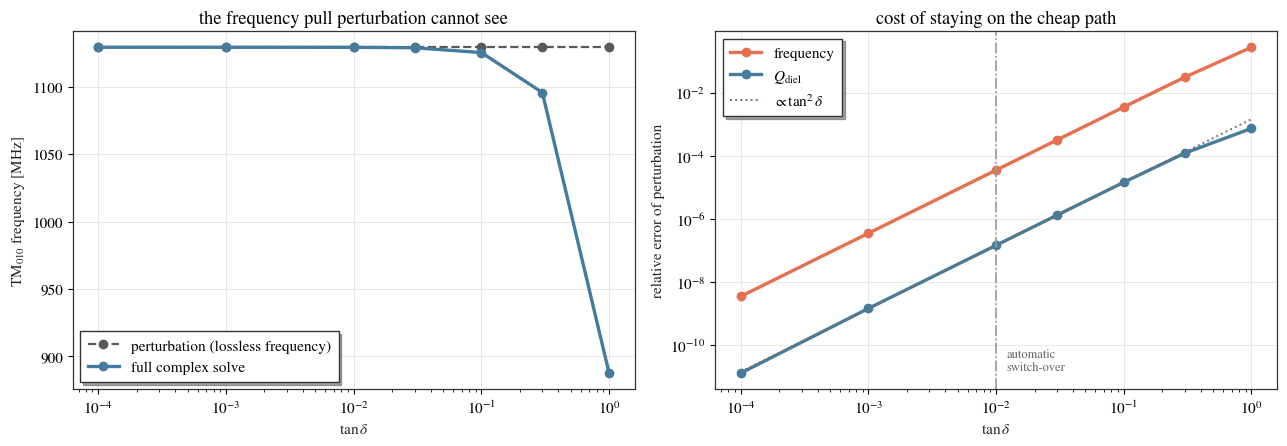

relative error of the perturbative answer
          freq [rel] Q_diel [rel]
tan_delta                        
0.0001      3.51e-09     1.31e-11
0.0010      3.51e-07     1.46e-09
0.0100      3.51e-05     1.46e-07
0.0300      3.16e-04     1.31e-06
0.1000      3.50e-03     1.44e-05
0.3000      3.07e-02     1.21e-04
1.0000      2.73e-01     7.34e-04


In [5]:
pert = sweep[sweep.loss_model == 'lossless'].set_index('tan_delta')
lossy = sweep[sweep.loss_model == 'lossy'].set_index('tan_delta')

df_err = pd.DataFrame({
    'freq': np.abs(pert['freq [MHz]'] - lossy['freq [MHz]']) / lossy['freq [MHz]'],
    'Q_diel': np.abs(pert['Q_diel'] - lossy['Q_diel']) / lossy['Q_diel'],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# Q_diel is ~1/tan_delta on both paths and the two curves would sit on top of each
# other on a log axis, so the left panel shows the FREQUENCY instead - where the
# two paths differ qualitatively, not just quantitatively.
axes[0].plot(pert.index, pert['freq [MHz]'], 'o--', color='0.35', lw=1.6,
             label='perturbation (lossless frequency)')
axes[0].plot(lossy.index, lossy['freq [MHz]'], 'o-', color=WARM[0], lw=2.4,
             label='full complex solve')
axes[0].set_xscale('log')
axes[0].set_xlabel(r'$\tan\delta$'); axes[0].set_ylabel('TM$_{010}$ frequency [MHz]')
axes[0].set_title('the frequency pull perturbation cannot see'); axes[0].legend()

for key, colour, label in [('freq', WARM[5], 'frequency'),
                           ('Q_diel', WARM[0], r'$Q_{\rm diel}$')]:
    axes[1].plot(df_err.index, df_err[key], 'o-', color=colour, lw=2.4, label=label)
# anchored on the tan_delta = 0.1 point, inside the range where the scaling holds
td = np.array(TAN_DELTAS)
anchor = df_err['Q_diel'].loc[0.1] / 0.1 ** 2
axes[1].plot(td, anchor * td ** 2, ':', color='0.45', lw=1.4,
             label=r'$\propto\tan^2\delta$')
axes[1].axvline(SWITCH_OVER, color='0.6', lw=1.2, ls='-.')
axes[1].text(SWITCH_OVER * 1.2, df_err.min().min(), 'automatic\nswitch-over',
             color='0.4', fontsize=9, va='bottom')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel(r'$\tan\delta$')
axes[1].set_ylabel('relative error of perturbation')
axes[1].set_title('cost of staying on the cheap path'); axes[1].legend()

plt.tight_layout(); plt.show()

print('relative error of the perturbative answer')
print(df_err.rename(columns=lambda c: c + ' [rel]').map('{:.2e}'.format))

The error follows $\tan^2\delta$, exactly as the theory says it should, and that
is what makes a fixed threshold defensible:

- at $\tan\delta = 10^{-4}$ (fused quartz, sapphire, a good alumina) the two
  paths agree to a few parts in $10^{9}$ — the complex solve buys nothing;
- at $10^{-2}$, the switch-over, the disagreement is a few parts in $10^{5}$;
- by $\tan\delta \sim 1$ (a ferrite, a HOM absorber) perturbation theory is wrong
  by *tens of percent* in both $Q$ and frequency, because the mode itself has
  moved and the lossless field it integrates over no longer exists.

Note that the perturbative frequency is not merely inaccurate — it does not move
at all. The real eigenproblem never saw $\varepsilon_r''$, so it cannot: only the
complex solve reports the frequency pull that a lossy material causes.

## 4. Reading the result

A run with a lossy material reports how its $Q$ was obtained, and splits the two
loss channels apart.

In [6]:
q = run(1e-3, 'auto')          # 1e-3 < 1e-2, so 'auto' picks the cheap path
for k in ['Q model', 'freq [MHz]', 'tan_delta []', 'Q_wall []', 'Q_diel []',
          'Q []', 'Pdiel [W]', 'Ploss [W]', 'G [Ohm]', 'U [J]']:
    v = q[k]
    print('  %-16s %s' % (k, v if isinstance(v, str) else '%.6g' % v))

eta = 1 / (q['Q_diel []'] * q['tan_delta []'])
print('\nelectric filling factor of the sleeve: %.3f' % eta)

  Q model          perturbation
  freq [MHz]       1129.45
  tan_delta []     0.001
  Q_wall []        7848.95
  Q_diel []        1033.38
  Q []             913.159
  Pdiel [W]        0.000191023
  Ploss [W]        2.51499e-05
  G [Ohm]          67.8895
  U [J]            2.78163e-11

electric filling factor of the sleeve: 0.968


`Q_diel` is $1/(\eta\tan\delta)$ with $\eta$ the fraction of the electric
energy inside the lossy region, so the printed filling factor is just that
relation read backwards — here the sleeve holds almost all of the TM$_{010}$
energy, which is why this cavity is such a demanding test.

Two conventions worth stating, because they are easy to get wrong:

- `Q []` is the total $Q$, wall and dielectric in parallel. The old wall-only
  number is still there as `Q_wall []`.
- `G [Ohm]` is $Q_{\rm wall}R_s$, unchanged. The geometry factor describes the wall
  and the mode shape only, so it stays independent of what fills the cavity.

A cavity with no dielectric loss reports none of these keys, and its `Q []` is
exactly the wall $Q$ it always was.

## 5. Overriding the automatic choice

The choice is yours to make. Forcing the cheap path on a strongly lossy material
is honoured — with a warning, because at that loss tangent a perturbative $Q$ is
wrong by percent and the frequency is wrong too.

In [7]:
cav = build('forced', 0.3)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    cav.eigenmode.run(polarisation='monopole', n_modes=2, mesh_config=MESH,
                      loss_model='lossless')

print('Q model:', cav.eigenmode.qois['Q model'])
print()
print([w.message for w in caught if 'loss_model' in str(w.message)][0])

Q model: perturbation

eigenmode_config['loss_model']='lossless' was requested but the largest loss tangent is 0.3 (> 0.01), where perturbation theory is no longer reliable: the O(tan_delta^2) eigenvalue error and the un-modelled field redistribution both matter. Continuing as asked — Q is tagged 'perturbation' in the QOIs. Use loss_model='lossy' (or 'auto') for the full complex eigenproblem.


## Practical guidance

- Leave `loss_model` alone. The automatic choice is right for almost every
  cavity: low-loss windows and liners take the free path, absorbers take the
  expensive one.
- Force `'lossy'` when you care about the *frequency* pull or the field
  distribution in a moderately lossy material, not just about $Q$ — the cheap path
  reports the lossless frequency by construction.
- Force `'lossless'` when you are sweeping geometry over many runs, know the
  material is low-loss, and want the speed. It stays accurate to $O(\tan^2\delta)$
  and still reports a dielectric $Q$.
- If a lossy run warns that a mode did not converge, raise
  `eigenmode_config['arnoldi_vectors']` (default 6).

## Limits

- $\mu_r$ is *rejected*, not ignored: magnetic materials are not modelled, and a
  cavity that declares one raises rather than returning a non-magnetic answer.
- Conductive loss, $\varepsilon_r'' = \sigma/(\omega\varepsilon_0)$, is not
  modelled, because it makes the permittivity itself depend on the answer. Pass a
  loss tangent evaluated at the frequency of interest instead.
- Eigenmode only, and native geometry only — the same limits every
  dielectric region has (see
  [the quartz-tube example](dielectric_quartz_tube.ipynb)).
- Wall loss is always treated perturbatively, on both paths. For a dielectric-loaded
  cavity it is a small correction next to the dielectric's anyway.